### OCV Models

This notebook showcases the different OCV models available and how to use them. Their implementation can be seen in `pcebatt.models.submodels.ocv`. We begin by importing the necessary libraries and modules.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# setup paths for relative imports
sys.path.append(os.path.abspath(".."))
from pcebatt.utils import load_validation
from pcebatt.core import Cell
from pcebatt.models.submodels.ocv import qOCV_POLY, qOCV_PCE, qOCV_Differential

In [2]:
time, current, measurement, soc, temperature, C_nom, C_nom_unc = load_validation(short=False)
cell_params = dict(initial_soc=soc[0], capacity=C_nom, capacity_unc=C_nom*C_nom_unc)
cell = Cell(**cell_params, load_default_config=False)
logger_level = "WARNING" # to avoid logging clutter

[Cell] Initializing empty cell model.


First in line is the standard qOCV_POLY model. It uses a polynomial to approximate the nonlinear OCV behavior of the cell. Although the model returns a standard deviation array, this is included only for compatibility with the rest of the library; the array itself contains only zeros.

In [3]:
cell.set_model(qOCV_POLY(logger_level=logger_level, order=6, config=None))
cell.solve(current=current, time=time, temperature=temperature)
v_poly_mean, v_poly_std = cell.voltage.mean, cell.voltage.std

**Note:** The `Cell` object was instantiated with `load_default_config=False`. This allows the user to load their own models into the `Cell`. However, some models, including all current OCV ones, require parametrization data to function properly. They need metadata about the simulation and the locations of the data files.  

There are two ways to provide this information:

1. **Leave the `config` parameter as `None`**  
   -> The models will load the default parameters from the [`../data`](../data) directory.

2. **Provide a configuration dictionary** with the required fields, for example:

```yaml
      simulation:
        temperatures: [15, 25, 35, 45]
        
        paths:
          ocv:
            ocv_folder: "absolute/path/to/data" # absolute path to the data
            file_naming_scheme: # template for reading files (temp stands for temperature)
              charge: "qocv_{temp}deg_charge.parquet"
              discharge: "qocv_{temp}deg_discharge.parquet"

From here onwards the config parameter is omitted (implicitly set to `None`). 

Next up is the qOCV_PCE model. It extends the qOCV_POLY approach by propagating uncertainty through analytical polynomial chaos expansions.

In [4]:
cell.set_model(qOCV_PCE(logger_level=logger_level))
cell.solve(current=current, time=time, temperature=temperature)
v_pce_mean, v_pce_std = cell.voltage.mean, cell.voltage.std

Finally, the qOCV_Differential model computes the OCV mean and its derivative numerically and stores them in a lookup table. During runtime, these values are then used to approximate the variance.

In [5]:
cell.set_model(qOCV_Differential(logger_level=logger_level))
cell.solve(current=current, time=time, temperature=temperature)
v_diff_mean, v_diff_std = cell.voltage.mean, cell.voltage.std

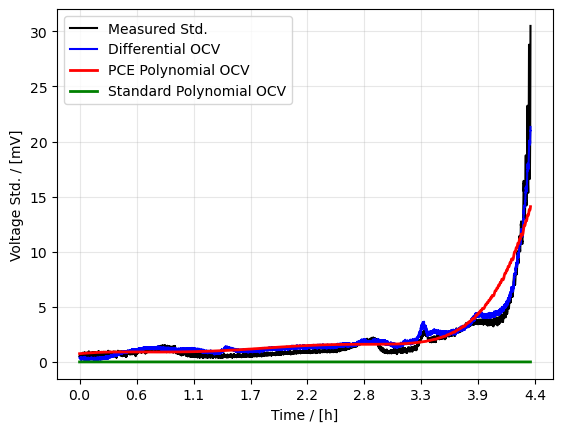

In [6]:
fig, ax = plt.subplots()
ax.plot(time, measurement[1], c='black', label='Measured Std.')
ax.plot(time, v_diff_std, c='b', label='Differential OCV')
ax.plot(time, v_pce_std, c='r', label='PCE Polynomial OCV', linewidth=2)
ax.plot(time, v_poly_std, c='g', label='Standard Polynomial OCV', linewidth=2)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/3600:.1f}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1000:g}'))
ax.set_ylabel('Voltage Std. / [mV]')
ax.set_xlabel('Time / [h]')
ax.grid(True, alpha=0.3)
plt.legend()
# plt.savefig("ocv_poly_vs_true.pdf", dpi=600)
plt.show()